In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

In [ ]:
df = pd.read_csv("skin_disorder.csv")

In [3]:
df.head()

,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,...,disappearance_of_the_granular_layer,vacuolisation_and_damage_of_basal_layer,spongiosis,saw-tooth_appearance_of_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_monoluclear_inflitrate,band-like_infiltrate,Age,class
0,2,2,0,3,0,0,0,0,1,0,...,0,0,3,0,0,0,1,0,55,2
1,3,3,3,2,1,0,0,0,1,1,...,0,0,0,0,0,0,1,0,8,1
2,2,1,2,3,1,3,0,3,0,0,...,0,2,3,2,0,0,2,3,26,3
3,2,2,2,0,0,0,0,0,3,2,...,3,0,0,0,0,0,3,0,40,1
4,2,3,2,2,2,2,0,2,0,0,...,2,3,2,3,0,0,2,3,45,3


In [4]:
columns = [
    "erythema","scaling","definite_borders","itching","koebner_phenomenon",
    "polygonal_papules","follicular_papules","oral_mucosal_involvement",
    "knee_elbow_involvement","scalp_involvement","family_history",
    "melanin_incontinence","eosinophils","PNL_infiltrate",
    "fibrosis_papillary_dermis","exocytosis","acanthosis",
    "hyperkeratosis","parakeratosis","clubbing_rete_ridges",
    "elongation_rete_ridges","thinning_suprapapillary_epidermis",
    "spongiform_pustule","munro_microabcess","focal_hypergranulosis",
    "disappearance_granular_layer","vacuolisation_basal_layer",
    "spongiosis","saw_tooth_retes","follicular_horn_plug",
    "perifollicular_parakeratosis","inflammatory_infiltrate",
    "band_like_infiltrate","age","target"
]

df.columns = columns

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 35 columns):
 #   Column                             Non-Null Count  Dtype 
---  ------                             --------------  ----- 
 0   erythema                           366 non-null    int64 
 1   scaling                            366 non-null    int64 
 2   definite_borders                   366 non-null    int64 
 3   itching                            366 non-null    int64 
 4   koebner_phenomenon                 366 non-null    int64 
 5   polygonal_papules                  366 non-null    int64 
 6   follicular_papules                 366 non-null    int64 
 7   oral_mucosal_involvement           366 non-null    int64 
 8   knee_elbow_involvement             366 non-null    int64 
 9   scalp_involvement                  366 non-null    int64 
 10  family_history                     366 non-null    int64 
 11  melanin_incontinence               366 non-null    int64 
 12  eosinoph

In [9]:
df["age"] = df["age"].replace("?", np.nan)
df["age"] = df["age"].astype(float)
df["age"].fillna(df["age"].median(), inplace=True)

C:\Users\ARTH ARVIND\AppData\Local\Temp\ipykernel_15880\4057487201.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["age"].fillna(df["age"].median(), inplace=True)


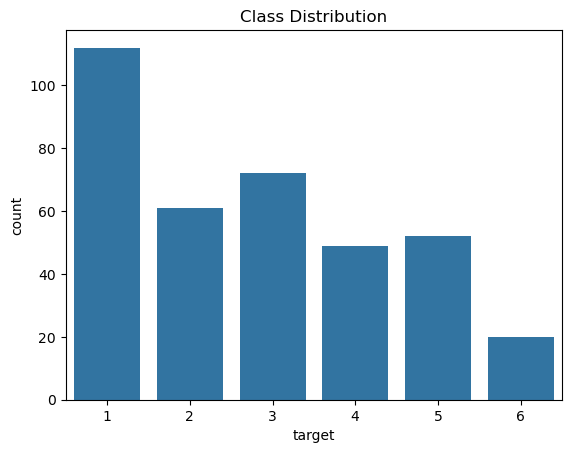

In [6]:
sns.countplot(x="target", data=df)
plt.title("Class Distribution")
plt.show()

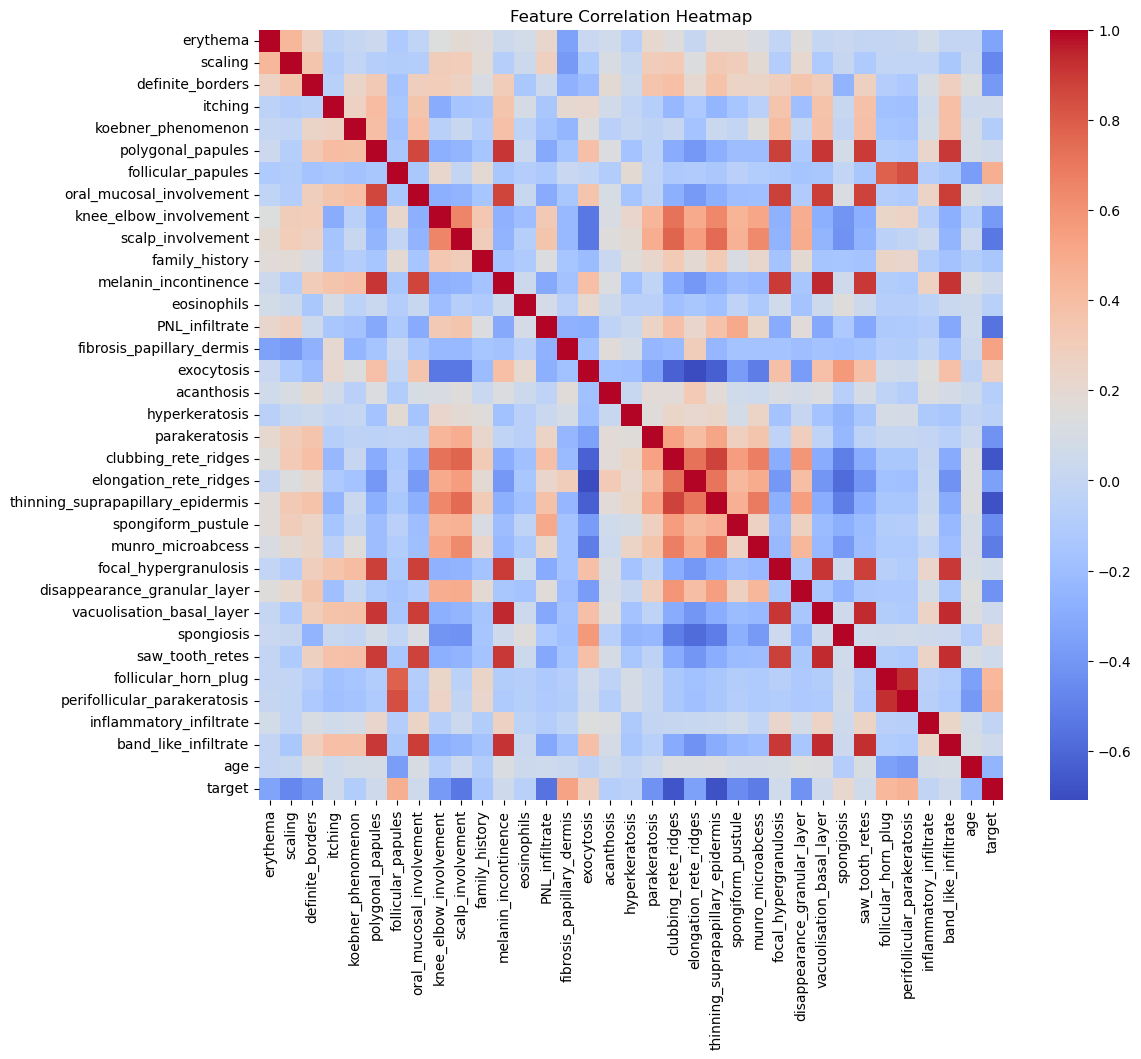

In [10]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

In [20]:
X = df.drop("target", axis=1)
y = df["target"] - 1

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [21]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, pred_lr))

Logistic Regression Accuracy: 0.9594594594594594


In [22]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
pred_knn = knn.predict(X_test)

print("KNN Accuracy:", accuracy_score(y_test, pred_knn))

KNN Accuracy: 0.9054054054054054


In [23]:
svm = SVC(kernel='rbf')
svm.fit(X_train, y_train)
pred_svm = svm.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, pred_svm))

SVM Accuracy: 0.972972972972973


In [24]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, pred_rf))

Random Forest Accuracy: 0.9594594594594594


In [33]:
xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=6,
    objective="multi:softprob",
    num_class=6,
    eval_metric="mlogloss",
    random_state=42
)

xgb.fit(X_train, y_train)
pred_xgb = xgb.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, pred_xgb))

XGBoost Accuracy: 0.9324324324324325


In [30]:
models = {
    "Logistic Regression": accuracy_score(y_test, pred_lr),
    "KNN": accuracy_score(y_test, pred_knn),
    "SVM": accuracy_score(y_test, pred_svm),
    "Random Forest": accuracy_score(y_test, pred_rf),
    "XGBoost": accuracy_score(y_test, pred_xgb)
}

pd.DataFrame(models.items(), columns=["Model", "Accuracy"]).sort_values(by="Accuracy", ascending=False)

,Model,Accuracy
2,SVM,0.972973
0,Logistic Regression,0.959459
3,Random Forest,0.959459
4,XGBoost,0.932432
1,KNN,0.905405


In [31]:
disease_map = {
    0: "Psoriasis",
    1: "Seborrheic Dermatitis",
    2: "Lichen Planus",
    3: "Pityriasis Rosea",
    4: "Chronic Dermatitis",
    5: "Pityriasis Rubra Pilaris"
}

predicted_disease = [disease_map[i] for i in pred_xgb[:5]]
predicted_disease

['Pityriasis Rosea',
 'Lichen Planus',
 'Pityriasis Rosea',
 'Psoriasis',
 'Pityriasis Rosea']

In [34]:
def train_test_accuracy(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))
    return train_acc, test_acc


In [35]:
results = []

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC(kernel='rbf'),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.1,
        max_depth=6,
        objective="multi:softprob",
        num_class=6,
        eval_metric="mlogloss",
        random_state=42
    )
}

for name, model in models.items():
    train_acc, test_acc = train_test_accuracy(
        model, X_train, X_test, y_train, y_test
    )
    results.append([name, train_acc, test_acc])


In [36]:
results_df = pd.DataFrame(
    results,
    columns=["Model", "Train Accuracy", "Test Accuracy"]
)

results_df.sort_values(by="Test Accuracy", ascending=False)


,Model,Train Accuracy,Test Accuracy
2,SVM,0.982877,0.972973
0,Logistic Regression,0.996575,0.959459
3,Random Forest,1.000000,0.959459
4,XGBoost,1.000000,0.932432
1,KNN,0.972603,0.905405


In [37]:
svm = SVC(kernel='rbf')
svm.fit(X_train, y_train)

y_test_pred = svm.predict(X_test)

In [38]:
comparison_df = pd.DataFrame({
    "Actual Class": y_test.values,
    "Predicted Class": y_test_pred
})

comparison_df.head(10)

,Actual Class,Predicted Class
0,1,1
1,2,2
2,3,3
3,0,0
4,3,3
5,2,2
6,3,3
7,0,0
8,1,1
9,2,2


In [39]:
disease_map = {
    0: "Psoriasis",
    1: "Seborrheic Dermatitis",
    2: "Lichen Planus",
    3: "Pityriasis Rosea",
    4: "Chronic Dermatitis",
    5: "Pityriasis Rubra Pilaris"
}

comparison_df["Actual Disease"] = comparison_df["Actual Class"].map(disease_map)
comparison_df["Predicted Disease"] = comparison_df["Predicted Class"].map(disease_map)

comparison_df.head(10)

,Actual Class,Predicted Class,Actual Disease,Predicted Disease
0,1,1,Seborrheic Dermatitis,Seborrheic Dermatitis
1,2,2,Lichen Planus,Lichen Planus
2,3,3,Pityriasis Rosea,Pityriasis Rosea
3,0,0,Psoriasis,Psoriasis
4,3,3,Pityriasis Rosea,Pityriasis Rosea
5,2,2,Lichen Planus,Lichen Planus
6,3,3,Pityriasis Rosea,Pityriasis Rosea
7,0,0,Psoriasis,Psoriasis
8,1,1,Seborrheic Dermatitis,Seborrheic Dermatitis
9,2,2,Lichen Planus,Lichen Planus


In [40]:
comparison_df["Correct Prediction"] = (
    comparison_df["Actual Class"] == comparison_df["Predicted Class"]
)

comparison_df["Correct Prediction"].value_counts()

Correct Prediction
True     72
False     2
Name: count, dtype: int64

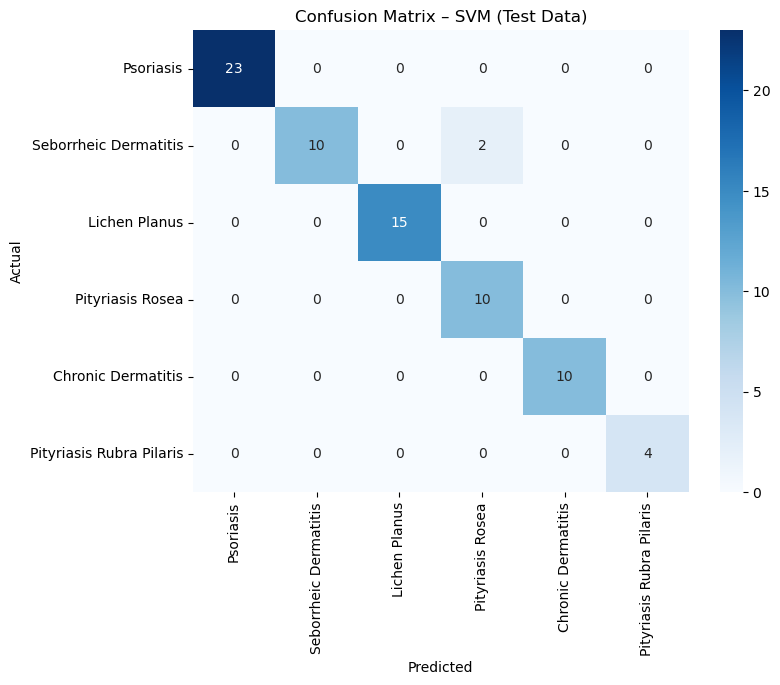

In [41]:
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=disease_map.values(),
    yticklabels=disease_map.values()
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – SVM (Test Data)")
plt.show()

In [42]:
print(classification_report(
    y_test,
    y_test_pred,
    target_names=disease_map.values()
))

                          precision    recall  f1-score   support

               Psoriasis       1.00      1.00      1.00        23
   Seborrheic Dermatitis       1.00      0.83      0.91        12
           Lichen Planus       1.00      1.00      1.00        15
        Pityriasis Rosea       0.83      1.00      0.91        10
      Chronic Dermatitis       1.00      1.00      1.00        10
Pityriasis Rubra Pilaris       1.00      1.00      1.00         4

                accuracy                           0.97        74
               macro avg       0.97      0.97      0.97        74
            weighted avg       0.98      0.97      0.97        74

